# 10_Hybrid_Model.ipynb
## FakeJobShield: proposed Hybrid XGBoost & Trust Score Generation
This notebook builds the final FakeJobShield Hybrid model. It combines text features (TF-IDF), cybersecurity feature indicators, and structured metadata. It trains a final XGBoost classifier, calculates a Trust Score using the formula: `Trust Score = (1 - Fraud Probability) * 100`, assigns jobs to risk bands, and saves the final models.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.sparse import hstack, csr_matrix
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
import os

# Adjust working directory if run from notebooks folder
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

sns.set_theme(style="whitegrid")


In [2]:
# Load combined text and cybersecurity dataset
df_cyber = pd.read_csv("data/cybersecurity_features.csv")
df_cleaned = pd.read_csv("data/cleaned_fake_job_postings.csv")

# Ensure target labels
df_cyber["fraudulent_int"] = df_cyber["fraudulent"].map({'t': 1, 'f': 0, '1': 1, '0': 0, 1: 1, 0: 0}).fillna(0).astype(int)
y = df_cyber["fraudulent_int"].values

# Load Vectorizer and Label Encoders
vectorizer = joblib.load("models/tfidf.pkl")
label_encoders = joblib.load("models/label_encoders.pkl")

# TF-IDF Features
x_tfidf = vectorizer.transform(df_cleaned["cleaned_text"].fillna(""))

# Cybersecurity Features
cyber_cols = [
    "req_otp", "req_aadhaar", "req_pan", "req_passport", "req_bank", "req_card", 
    "req_reg_fee", "req_proc_fee", "sensitive_data_score", "urgency_count", 
    "has_personal_email", "has_suspicious_url"
]
x_cyber = df_cyber[cyber_cols].values

# Structured Categorical Features
cat_cols = ["employment_type", "required_experience", "required_education", "industry", "function"]
encoded_cats = []
for col in cat_cols:
    df_cyber[col] = df_cyber[col].fillna("missing").astype(str)
    le = label_encoders[col]
    df_cyber[col + "_encoded"] = le.transform(df_cyber[col])
    encoded_cats.append(df_cyber[col + "_encoded"].values.reshape(-1, 1))
x_categorical = np.hstack(encoded_cats)

# Structured Binary Features
for col in ["telecommuting", "has_company_logo", "has_questions"]:
    df_cyber[col] = df_cyber[col].map({'t': 1, 'f': 0, '1': 1, '0': 0, 1: 1, 0: 0, True: 1, False: 0}).fillna(0).astype(int)
x_binary = df_cyber[["telecommuting", "has_company_logo", "has_questions"]].values

# Combine everything
x_hybrid = hstack([x_tfidf, csr_matrix(x_cyber), csr_matrix(x_categorical), csr_matrix(x_binary)]).tocsr()
print("Hybrid Feature Matrix shape:", x_hybrid.shape)


Hybrid Feature Matrix shape: (17880, 10020)


In [3]:
# Split Data
x_train, x_test, y_train, y_test = train_test_split(
    x_hybrid, y, test_size=0.15, stratify=y, random_state=42
)


In [4]:
# Train Hybrid Model
hybrid_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=20,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print("Training Hybrid Model...")
hybrid_model.fit(x_train, y_train)
print("Training Complete!")


Training Hybrid Model...


Training Complete!


In [5]:
# Evaluate Hybrid Model
probs = hybrid_model.predict_proba(x_test)[:, 1]
preds = hybrid_model.predict(x_test)

print("Hybrid Model Evaluation:")
print(classification_report(y_test, preds))
print("Test F1 Score:", f1_score(y_test, preds))
print("Test ROC AUC Score:", roc_auc_score(y_test, probs))


Hybrid Model Evaluation:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2552
           1       0.76      0.82      0.79       130

    accuracy                           0.98      2682
   macro avg       0.87      0.90      0.89      2682
weighted avg       0.98      0.98      0.98      2682

Test F1 Score: 0.7896678966789668
Test ROC AUC Score: 0.9904870991077888


## Trust Score Framework\nWe calculate the Trust Score based on the formula: `Trust Score = (1 - Fraud Probability) * 100`\n\n**Trust Bands:**\n* 81-100: **Trusted**\n* 61-80: **Low Risk**\n* 41-60: **Medium Risk**\n* 21-40: **High Risk**\n* 0-20: **Highly Fraudulent**


In [6]:
# Calculate Trust Scores
trust_scores = (1 - probs) * 100

def get_risk_level(score):
    if score >= 81: return "Trusted"
    elif score >= 61: return "Low Risk"
    elif score >= 41: return "Medium Risk"
    elif score >= 21: return "High Risk"
    else: return "Highly Fraudulent"

risk_levels = [get_risk_level(s) for s in trust_scores]

# Distribution analysis
results_df = pd.DataFrame({
    "actual_label": y_test,
    "fraud_prob": probs,
    "trust_score": trust_scores,
    "risk_level": risk_levels
})

print("Average Trust Score for Genuine Job Postings (Label=0):")
print(results_df[results_df["actual_label"] == 0]["trust_score"].mean())

print("\nAverage Trust Score for Fraudulent Job Postings (Label=1):")
print(results_df[results_df["actual_label"] == 1]["trust_score"].mean())


Average Trust Score for Genuine Job Postings (Label=0):
96.779045

Average Trust Score for Fraudulent Job Postings (Label=1):
18.215258


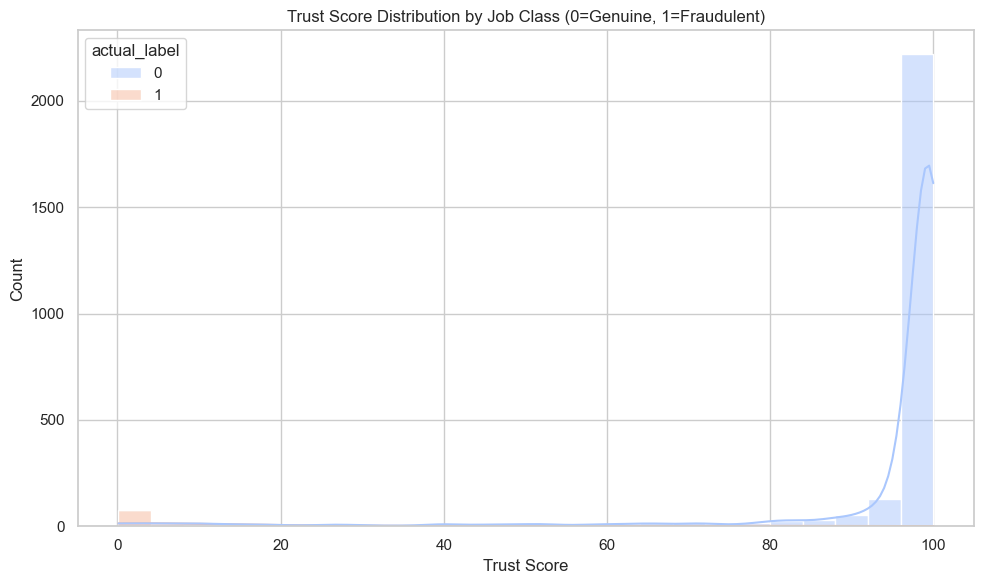

In [7]:
# Plot trust score distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=results_df, x="trust_score", hue="actual_label", kde=True, bins=25, palette="coolwarm", multiple="stack")
plt.title("Trust Score Distribution by Job Class (0=Genuine, 1=Fraudulent)")
plt.xlabel("Trust Score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("results/trust_score_distribution.png", dpi=150)
plt.show()


In [8]:
# Risk levels table
risk_summary = results_df.groupby(["risk_level", "actual_label"]).size().unstack(fill_value=0)
print("Risk Level Matrix (Risk Level vs Actual Label):")
print(risk_summary)


Risk Level Matrix (Risk Level vs Actual Label):
actual_label          0   1
risk_level                 
High Risk            17  10
Highly Fraudulent     4  95
Low Risk             56  14
Medium Risk          31   5
Trusted            2444   6


In [9]:
# Export Hybrid Model & Metadata mapping
joblib.dump(hybrid_model, "models/hybrid_model.pkl")

# Save a configuration dictionary
hybrid_metadata = {
    "cyber_cols": cyber_cols,
    "cat_cols": cat_cols,
    "binary_cols": ["telecommuting", "has_company_logo", "has_questions"]
}
joblib.dump(hybrid_metadata, "models/hybrid_metadata.pkl")

print("Saved hybrid_model.pkl and hybrid_metadata.pkl to 'models/'")


Saved hybrid_model.pkl and hybrid_metadata.pkl to 'models/'
